In [1]:
!pip install tensorflow numpy matplotlib

In [2]:
import tensorflow  as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [6]:
x_train, x_test = x_train/255.0, x_test/255.0

In [8]:
xlabels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

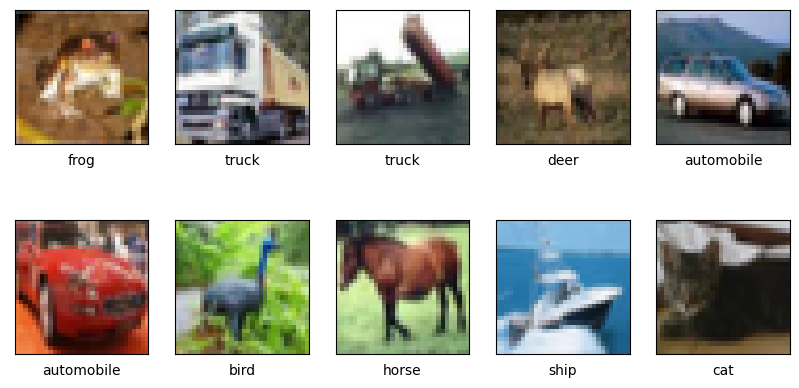

In [12]:
plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(xlabels[y_train[i][0]])
plt.show()

In [21]:
model = Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

In [22]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy", metrics="accuracy")

In [23]:
hist = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 [==============================] - 32s 19ms/step - loss: 1.4806 - accuracy: 0.4600 - val_loss: 1.2280 - val_accuracy: 0.5591
Epoch 2/10
1563/1563 [==============================] - 41s 27ms/step - loss: 1.1135 - accuracy: 0.6073 - val_loss: 1.1264 - val_accuracy: 0.6068
Epoch 3/10
1563/1563 [==============================] - 43s 28ms/step - loss: 0.9704 - accuracy: 0.6577 - val_loss: 1.0507 - val_accuracy: 0.6341
Epoch 4/10
1563/1563 [==============================] - 42s 27ms/step - loss: 0.8670 - accuracy: 0.6971 - val_loss: 0.9194 - val_accuracy: 0.6807
Epoch 5/10
1563/1563 [==============================] - 43s 27ms/step - loss: 0.7957 - accuracy: 0.7211 - val_loss: 0.9222 - val_accuracy: 0.6819
Epoch 6/10
1563/1563 [==============================] - 46s 29ms/step - loss: 0.7330 - accuracy: 0.7425 - val_loss: 0.8713 - val_accuracy: 0.7048
Epoch 7/10
1563/1563 [==============================] - 46s 29ms/step - loss: 0.6788 - accuracy: 0.7633 - val_loss: 0.8270 -

In [24]:
test_loss, test_acc = model.evaluate(x_test, y_test)

313/313 [==============================] - 3s 9ms/step - loss: 0.8728 - accuracy: 0.7119


In [26]:
print(f"Accuracy: {test_acc*100:.2f}%")

Accuracy: 71.19%


In [27]:
y_pred = model.predict(x_test[:5])

1/1 [==============================] - 0s 174ms/step


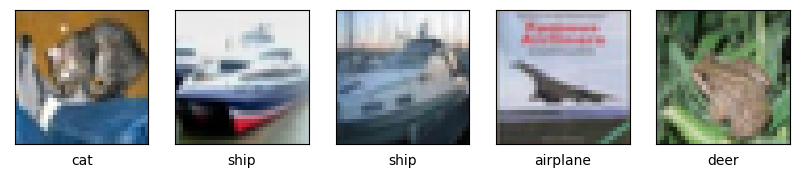

In [30]:
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i])
    plt.xlabel(xlabels[np.argmax(y_pred[i])])
plt.show()

In [33]:
model.save("cnn-tensorflow-seq-cifar10.keras")

In [35]:
from tensorflow import keras
ctsc = keras.models.load_model("cnn-tensorflow-seq-cifar10.keras")

In [36]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 conv2d_5 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 flatten (Flatten)           (None, 1024)              0